# One Billion Word - EDA Notebook (Task 3.2)


In [1]:
import os
import re
import tarfile
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, load_from_disk
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

In [2]:
# Define the root directory of the project
PROJECT_ROOT = Path.cwd().resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
DATASET_DIR = RAW_DIR / 'one-billion-word'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'eda' / 'one-billion-word'
DOCS_DIR = PROJECT_ROOT / 'docs'

# Create necessary directories if they do not exist
OUT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_URL = 'https://www.statmt.org/lm-benchmark/1-billion-word-language-modeling-benchmark-r13output.tar.gz'
ARCHIVE_PATH = RAW_DIR / 'one-billion-word.tar.gz'
EXTRACT_DIR = RAW_DIR / 'one-billion-word-source'
SAMPLE_SIZE = 1_000_000
SEED = 42

print(f"Project Root: {PROJECT_ROOT}")


Project Root: /content


## 1) Download + Build dataset from source


In [3]:

!mkdir -p /content/data/raw/one-billion-word-source
print("Downloading...")
!wget -c https://www.statmt.org/lm-benchmark/1-billion-word-language-modeling-benchmark-r13output.tar.gz -O /content/data/raw/one-billion-word.tar.gz

# 4.Unzip
print("Unzip..")
!tar -xzvf /content/data/raw/one-billion-word.tar.gz -C /content/data/raw/one-billion-word-source

Downloading...
--2026-04-05 11:49:20--  https://www.statmt.org/lm-benchmark/1-billion-word-language-modeling-benchmark-r13output.tar.gz
Resolving www.statmt.org (www.statmt.org)... 129.215.32.28
Connecting to www.statmt.org (www.statmt.org)|129.215.32.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1792209805 (1.7G) [application/x-gzip]
Saving to: ‘/content/data/raw/one-billion-word.tar.gz’

/content/data/raw/o 100%[===================>]   1.67G  21.1MB/s    in 85s     

2026-04-05 11:50:45 (20.2 MB/s) - ‘/content/data/raw/one-billion-word.tar.gz’ saved [1792209805/1792209805]

Unzip..
1-billion-word-language-modeling-benchmark-r13output/
1-billion-word-language-modeling-benchmark-r13output/training-monolingual.tokenized.shuffled/
1-billion-word-language-modeling-benchmark-r13output/training-monolingual.tokenized.shuffled/news.en-00024-of-00100
1-billion-word-language-modeling-benchmark-r13output/training-monolingual.tokenized.shuffled/news.en-00057-of-0010

In [4]:
def build_one_billion_word_dataset():
    RAW_DIR.mkdir(parents=True, exist_ok=True)

    if DATASET_DIR.exists():
        print(f'Loading dataset from disk: {DATASET_DIR}')
        return load_from_disk(str(DATASET_DIR))

    if not ARCHIVE_PATH.exists():
        print('Downloading One Billion Word archive...')
        urllib.request.urlretrieve(SOURCE_URL, ARCHIVE_PATH)
        print(f'Downloaded archive: {ARCHIVE_PATH}')

    if not EXTRACT_DIR.exists():
        EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        print('Extracting archive...')
        with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
            tar.extractall(path=EXTRACT_DIR)
        print(f'Extracted to: {EXTRACT_DIR}')

    root = EXTRACT_DIR / '1-billion-word-language-modeling-benchmark-r13output'
    train_dir = root / 'training-monolingual.tokenized.shuffled'
    heldout_dir = root / 'heldout-monolingual.tokenized.shuffled'

    train_files = sorted(str(p) for p in train_dir.glob('news.en-*') if p.is_file())
    heldout_files = sorted(str(p) for p in heldout_dir.glob('news.en.heldout-*') if p.is_file())

    if not train_files:
        raise FileNotFoundError(f'No train files found under: {train_dir}')
    if not heldout_files:
        raise FileNotFoundError(f'No heldout files found under: {heldout_dir}')

    print(f'Train files: {len(train_files)} | Heldout files: {len(heldout_files)}')

    ds = load_dataset(
        'text',
        data_files={
            'train': train_files,
            'validation': heldout_files,
            'test': heldout_files,
        },
    )

    ds.save_to_disk(str(DATASET_DIR))
    print(f'Saved dataset to: {DATASET_DIR}')
    return ds

ds = build_one_billion_word_dataset()
ds


Train files: 99 | Heldout files: 50


Resolving data files:   0%|          | 0/99 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Saving the dataset (0/9 shards):   0%|          | 0/30301028 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/306688 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/306688 [00:00<?, ? examples/s]

Saved dataset to: /content/data/raw/one-billion-word


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 30301028
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 306688
    })
    test: Dataset({
        features: ['text'],
        num_rows: 306688
    })
})

In [5]:
print('Dataset splits:')
for split in ds.keys():
    print(f'- {split}: {len(ds[split]):,} rows')


Dataset splits:
- train: 30,301,028 rows
- validation: 306,688 rows
- test: 306,688 rows


## 2) Sample data for EDA

In [6]:
train = ds['train']
sample = train.shuffle(seed=SEED).select(range(min(SAMPLE_SIZE, len(train))))
print(f'Using sampled rows: {len(sample):,}')
sample[0]


Using sampled rows: 1,000,000


{'text': "A New Zealand lawmaker said Qian 's grandmother may soon come to be with her ."}

## 3) EDA core statistics

In [7]:
TOKEN_RE = re.compile(r'\S+')
PUNCT_RE = re.compile(r'[^\w\s]')
DIGIT_RE = re.compile(r'\d')

token_counter = Counter()
char_counter = Counter()
sentence_lengths = []

num_rows = 0
num_empty = 0
num_with_digit = 0
num_with_punct = 0

for row in tqdm(sample, desc='Scanning sample'):
    text = row['text']
    num_rows += 1

    if not text or not text.strip():
        num_empty += 1
        continue

    text = re.sub(r'\s+', ' ', text).strip()
    toks = TOKEN_RE.findall(text)

    sentence_lengths.append(len(toks))
    token_counter.update(toks)

    if DIGIT_RE.search(text):
        num_with_digit += 1
    if PUNCT_RE.search(text):
        num_with_punct += 1

    char_counter.update(text)

total_tokens = int(sum(token_counter.values()))
vocab_size = len(token_counter)
char_vocab_size = len(char_counter)

summary = {
    'sample_rows': num_rows,
    'non_empty_rows': num_rows - num_empty,
    'empty_rows': num_empty,
    'total_tokens': total_tokens,
    'vocab_size_raw': vocab_size,
    'char_vocab_size': char_vocab_size,
    'avg_sentence_len_tokens': float(np.mean(sentence_lengths)) if sentence_lengths else 0.0,
    'median_sentence_len_tokens': float(np.median(sentence_lengths)) if sentence_lengths else 0.0,
    'p95_sentence_len_tokens': float(np.percentile(sentence_lengths, 95)) if sentence_lengths else 0.0,
    'max_sentence_len_tokens': int(np.max(sentence_lengths)) if sentence_lengths else 0,
    'pct_rows_with_digits': (num_with_digit / max(1, num_rows)) * 100,
    'pct_rows_with_punctuation': (num_with_punct / max(1, num_rows)) * 100,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUT_DIR / 'summary_stats.csv', index=False)
summary_df


Scanning sample:   0%|          | 0/1000000 [00:00<?, ?it/s]

,sample_rows,non_empty_rows,empty_rows,total_tokens,vocab_size_raw,char_vocab_size,avg_sentence_len_tokens,median_sentence_len_tokens,p95_sentence_len_tokens,max_sentence_len_tokens,pct_rows_with_digits,pct_rows_with_punctuation
0,1000000,1000000,0,25356662,365569,239,25.356662,24.0,47.0,1901,28.3218,100.0


In [8]:
# Rare word stats
freq_values = np.array(list(token_counter.values()), dtype=np.int64)
rare_1 = int((freq_values == 1).sum())
rare_lt5 = int((freq_values < 5).sum())

rare_df = pd.DataFrame([
    {
        'vocab_size': vocab_size,
        'rare_freq_eq_1': rare_1,
        'rare_freq_lt_5': rare_lt5,
        'rare_eq_1_ratio': rare_1 / max(1, vocab_size),
        'rare_lt_5_ratio': rare_lt5 / max(1, vocab_size),
    }
])
rare_df.to_csv(OUT_DIR / 'rare_token_stats.csv', index=False)
rare_df


,vocab_size,rare_freq_eq_1,rare_freq_lt_5,rare_eq_1_ratio,rare_lt_5_ratio
0,365569,199643,278380,0.546116,0.761498


## 4) Plots

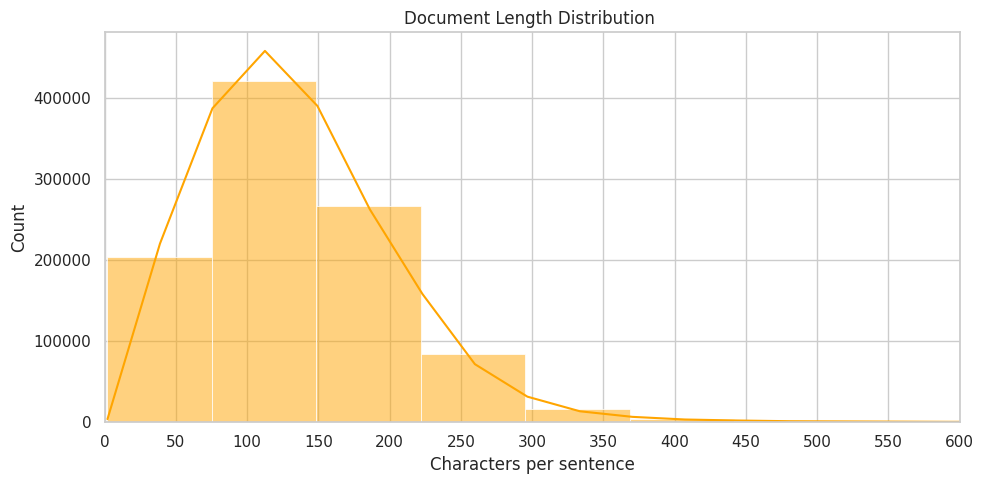

In [9]:
# Calculate length by characters (Document/Sentence Character Length)
char_lengths = [len(row['text']) for row in sample if row['text']]

plt.figure(figsize=(10, 5))
# KDE helps visualize the smooth probability density of lengths
sns.histplot(char_lengths, bins=100, color='orange', kde=True)

# We cap at 600 characters to focus on the majority of the data.
plt.xlim(0, 600)
plt.xticks(np.arange(0, 601, 50))

plt.title('Document Length Distribution ')
plt.xlabel('Characters per sentence')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OUT_DIR / 'document_char_distribution.png', dpi=150)
plt.show()

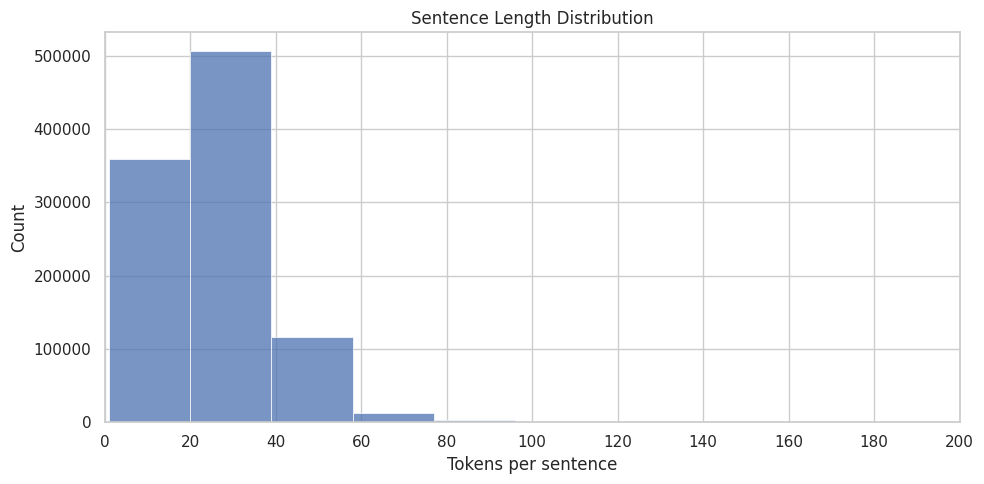

In [10]:
# Sentence length distribution
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=100, kde=False)

plt.xticks(np.arange(0, 201, 20))
# interval [0, 200]
plt.xlim(0, 200)

plt.title('Sentence Length Distribution')
plt.xlabel('Tokens per sentence')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OUT_DIR / 'length_distribution_200.png', dpi=150)
plt.show()

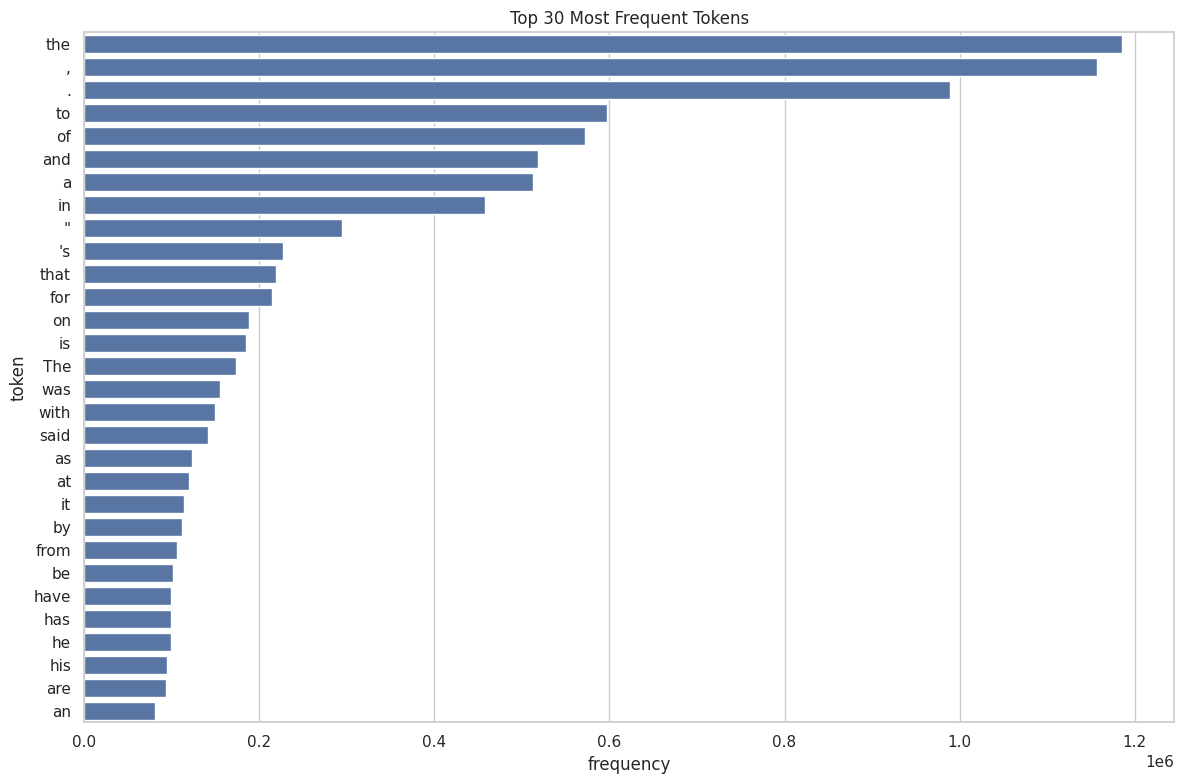

In [11]:
# Top tokens
top_n = 50
top_df = pd.DataFrame(token_counter.most_common(top_n), columns=['token', 'frequency'])
top_df.to_csv(OUT_DIR / 'top_tokens.csv', index=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_df.head(30), x='frequency', y='token', orient='h')
plt.title('Top 30 Most Frequent Tokens')
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_tokens.png', dpi=150)
plt.show()


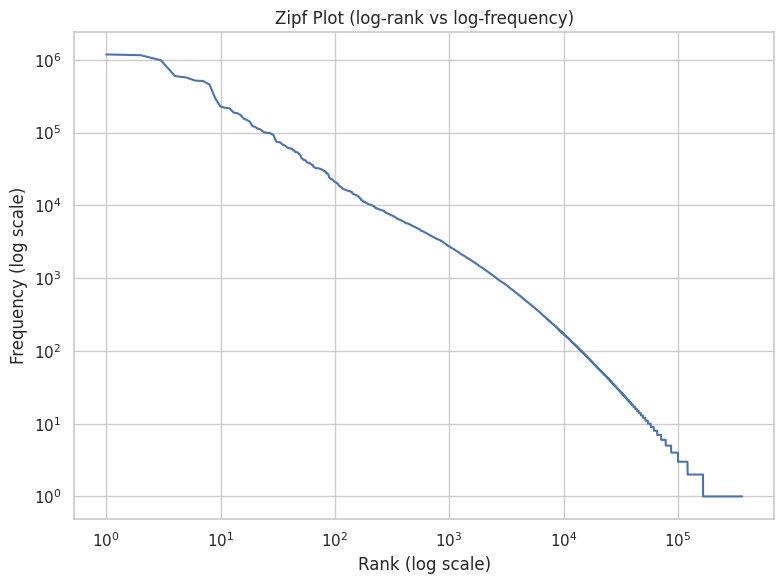

In [12]:
# Zipf plot
freqs = np.array(sorted(token_counter.values(), reverse=True), dtype=np.int64)
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(8, 6))
plt.loglog(ranks, freqs)
plt.title('Zipf Plot (log-rank vs log-frequency)')
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'zipf_plot.png', dpi=150)
plt.show()


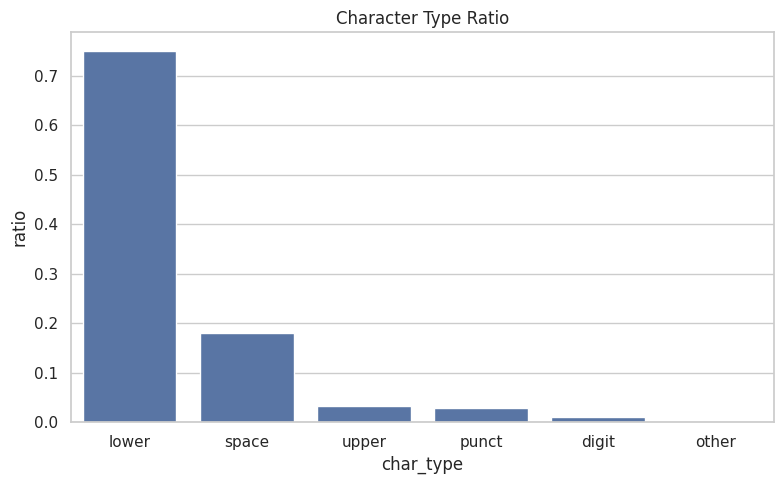

,char_type,count,ratio
2,lower,101938597,0.750919
1,space,24356662,0.179421
0,upper,4263170,0.031404
3,punct,3872516,0.028526
4,digit,1315491,0.009690
5,other,5316,0.000039


In [13]:
# Character type distribution
def char_type(ch: str) -> str:
    if ch.isupper():
        return 'upper'
    if ch.islower():
        return 'lower'
    if ch.isdigit():
        return 'digit'
    if ch.isspace():
        return 'space'
    if re.match(r'[^\w\s]', ch):
        return 'punct'
    return 'other'

char_type_counter = Counter()
for ch, c in char_counter.items():
    char_type_counter[char_type(ch)] += c

char_df = pd.DataFrame([
    {'char_type': k, 'count': v} for k, v in char_type_counter.items()
]).sort_values('count', ascending=False)
char_df['ratio'] = char_df['count'] / char_df['count'].sum()
char_df.to_csv(OUT_DIR / 'char_type_distribution.csv', index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=char_df, x='char_type', y='ratio')
plt.title('Character Type Ratio')
plt.tight_layout()
plt.savefig(OUT_DIR / 'char_type_distribution.png', dpi=150)
plt.show()

char_df


## 5) Tokenization-focused analysis (Word/Char/BPE hypothesis)

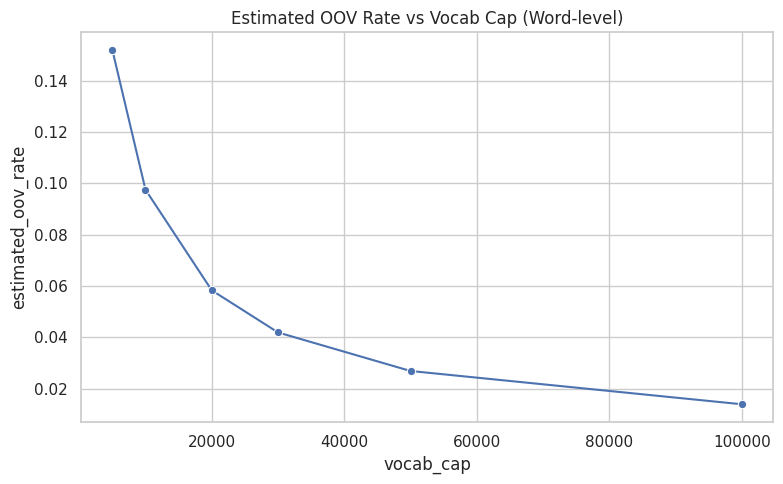

,vocab_cap,estimated_oov_rate
0,5000,0.151870
1,10000,0.097481
2,20000,0.058303
3,30000,0.041906
4,50000,0.026893
5,100000,0.013932


In [14]:
# OOV simulation for word-level with capped vocab
sorted_tokens = token_counter.most_common()
total_token_count = sum(freq for _, freq in sorted_tokens)

def oov_rate(vocab_cap: int) -> float:
    top_vocab = set(tok for tok, _ in sorted_tokens[:vocab_cap])
    in_vocab = sum(freq for tok, freq in sorted_tokens if tok in top_vocab)
    return 1.0 - (in_vocab / total_token_count if total_token_count > 0 else 0.0)

caps = [5000, 10000, 20000, 30000, 50000, 100000]
oov_df = pd.DataFrame({
    'vocab_cap': caps,
    'estimated_oov_rate': [oov_rate(c) for c in caps],
})
oov_df.to_csv(OUT_DIR / 'oov_simulation_wordlevel.csv', index=False)

plt.figure(figsize=(8, 5))
sns.lineplot(data=oov_df, x='vocab_cap', y='estimated_oov_rate', marker='o')
plt.title('Estimated OOV Rate vs Vocab Cap (Word-level)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'oov_simulation_wordlevel.png', dpi=150)
plt.show()

oov_df


In [15]:
# Sequence length comparison (rough): word vs char
small_sample = sample.select(range(min(5000, len(sample))))
word_lens = []
char_lens = []

for row in small_sample:
    text = row['text']
    if not text or not text.strip():
        continue
    word_lens.append(len(TOKEN_RE.findall(text)))
    char_lens.append(len(text.replace(' ', '')))

compare_df = pd.DataFrame([
    {'tokenization': 'word-level', 'avg_sequence_length': np.mean(word_lens)},
    {'tokenization': 'char-level(no-space)', 'avg_sequence_length': np.mean(char_lens)},
    {'tokenization': 'bpe-8k(hypothesis)', 'avg_sequence_length': np.nan},
    {'tokenization': 'bpe-16k(hypothesis)', 'avg_sequence_length': np.nan},
    {'tokenization': 'bpe-32k(hypothesis)', 'avg_sequence_length': np.nan},
])

compare_df.to_csv(OUT_DIR / 'token_length_compare_word_char_bpe.csv', index=False)
compare_df


,tokenization,avg_sequence_length
0,word-level,25.1440
1,char-level(no-space),110.0802
2,bpe-8k(hypothesis),NaN
3,bpe-16k(hypothesis),NaN
4,bpe-32k(hypothesis),NaN
